# Tutorial 7 — Bayesian Hierarchical Meta-d'

This tutorial uses **exactly the same data** as the
[metadpy Bayesian tutorial](https://github.com/LegrandNico/metadpy)
and [comparison with HMeta-d toolbox](https://github.com/LegrandNico/metadpy/tree/master/docs/source/examples) (`3-Comparison with the hmeta-d toolbox.ipynb`; GitHub's notebook viewer currently fails to render this specific file due to an upstream `metadata.widgets` bug — download it directly to view)
notebook, so outputs can be compared directly.

| Section | Data | What runs |
|---------|------|-----------|
| 1–3 | Canonical single-subject (`nR_S1`, `nR_S2`) | MLE + all 3 Bayesian parameterizations |
| 4–6 | `rm.txt` (20 subjects × 2 conditions, metadpy dataset) | Group MLE + group Bayesian |

**metadpy reference values** (from their published tutorial):
- `d1 = 1.534 ± 0.135`, `c1 = -0.006 ± 0.066`, `meta_d = 1.567 ± 0.201`

**Backend**: `fit_group(..., method='bayesian')` delegates to
`fit_meta_formula` via cmdstanpy — no R required.

```bash
pip install cmdstanpy
python -c "import cmdstanpy; cmdstanpy.install_cmdstan()"
```

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from metasignal import stdpy
from metasignal.stdpy import fit_group

RNG = np.random.default_rng(42)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "font.size": 11,
})

## 2. Canonical Dataset (same as metadpy tutorial)

From Fleming (2017) / metadpy `Example 2` and `Tutorial 3`.
Single subject, 4 confidence levels → 8-element count arrays.

In [2]:
# Identical to metadpy tutorial data
nR_S1 = np.array([52, 32, 35, 37, 26, 12,  4,  2], dtype=float)
nR_S2 = np.array([ 2,  5, 15, 22, 33, 38, 40, 45], dtype=float)
n_ratings = 4

print("nR_S1:", nR_S1)
print("nR_S2:", nR_S2)
print(f"Total S1 trials: {nR_S1.sum():.0f}  |  Total S2 trials: {nR_S2.sum():.0f}")

nR_S1: [52. 32. 35. 37. 26. 12.  4.  2.]
nR_S2: [ 2.  5. 15. 22. 33. 38. 40. 45.]
Total S1 trials: 200  |  Total S2 trials: 200


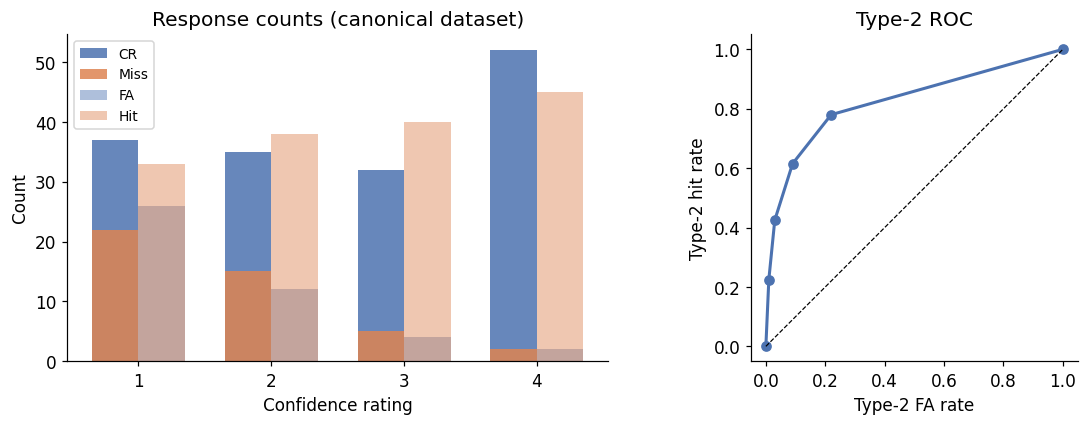

In [3]:
# Confidence histogram + Type-2 ROC (mirrors metadpy plotting style)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ratings = np.arange(1, n_ratings + 1)
w = 0.35

ax = axes[0]
ax.bar(ratings - w/2, nR_S1[:n_ratings][::-1], w, label="CR",   color="#4C72B0", alpha=0.85)
ax.bar(ratings - w/2, nR_S2[:n_ratings][::-1], w, label="Miss", color="#DD8452", alpha=0.85)
ax.bar(ratings + w/2, nR_S1[n_ratings:],        w, label="FA",   color="#4C72B0", alpha=0.45)
ax.bar(ratings + w/2, nR_S2[n_ratings:],        w, label="Hit",  color="#DD8452", alpha=0.45)
ax.set_xlabel("Confidence rating"); ax.set_ylabel("Count")
ax.set_title("Response counts (canonical dataset)")
ax.set_xticks(ratings); ax.legend(fontsize=9)

ax2 = axes[1]
n_S1, n_S2 = nR_S1.sum(), nR_S2.sum()
hr2 = [nR_S2[n_ratings:][k:].sum() / n_S2 for k in range(n_ratings)]
fr2 = [nR_S1[n_ratings:][k:].sum() / n_S1 for k in range(n_ratings)]
ax2.plot([0] + fr2[::-1] + [1], [0] + hr2[::-1] + [1], "o-", color="#4C72B0", lw=2, label="Type-2 ROC")
ax2.plot([0, 1], [0, 1], "k--", lw=0.8)
ax2.set_xlabel("Type-2 FA rate"); ax2.set_ylabel("Type-2 hit rate")
ax2.set_title("Type-2 ROC"); ax2.set_aspect("equal")

plt.tight_layout()
plt.show()

## 3. MLE Baseline

Compare `metasignal` MLE with metadpy's published values.

In [4]:
mle = stdpy.fit_meta_d_mle(nR_S1, nR_S2)

# metadpy published MLE values (Example 1 / Tutorial 2)
metadpy_mle = dict(dprime=1.5350, meta_d=1.6338, m_ratio=1.0643, m_diff=0.0988)

print("=== metasignal MLE ===")
print(f"  da       : {mle['da']:.4f}")
print(f"  meta_da  : {mle['meta_da']:.4f}")
print(f"  M_ratio  : {mle['M_ratio']:.4f}")
print(f"  M_diff   : {mle['M_diff']:.4f}")
print()
print("=== metadpy MLE (reference) ===")
for k, v in metadpy_mle.items():
    print(f"  {k:<10}: {v:.4f}")
print()
print(f"Δ M_ratio: {abs(mle['M_ratio'] - metadpy_mle['m_ratio']):.4f}")
print("(minor difference: equal- vs unequal-variance SDT parameterisation)")

=== metasignal MLE ===
  da       : 1.5444
  meta_da  : 1.6538
  M_ratio  : 1.0709
  M_diff   : 0.1095

=== metadpy MLE (reference) ===
  dprime    : 1.5350
  meta_d    : 1.6338
  m_ratio   : 1.0643
  m_diff    : 0.0988

Δ M_ratio: 0.0066
(minor difference: equal- vs unequal-variance SDT parameterisation)


## 4. Bayesian Subject-Level — All Three Parameterizations

We call `fit_group(nR_S1=..., nR_S2=..., method='bayesian')` which delegates
to `fit_meta_formula` via cmdstanpy.

| `parameterization` | Model | Group parameter |
|--------------------|-------|-----------------|
| `'mratio'` | Fleming (2017) HMeta-d | log M-ratio = log(meta-d'/d') |
| `'meta_noise'` | Maniscalco & Lau (2014) / Guggenmos (2022) | log σ_meta |
| `'casandre'` | Boundy-Singer et al. (2023) | log φ (meta-uncertainty) |

> **Comparison target** (metadpy `Example 2`, PyMC NUTS, 4 chains × 1000 draws):
> `meta_d = 1.567 ± 0.201`,  `d1 = 1.534 ± 0.135`,  `c1 = -0.006 ± 0.066`

In [5]:
# --- mratio (Fleming HMeta-d, same model as metadpy hmetad()) ---
fit_mratio = fit_group(
    nR_S1=nR_S1, nR_S2=nR_S2, nRatings=n_ratings,
    method="bayesian", parameterization="mratio",
    chains=4, n_iter=2000, warmup=1000, seed=42,
)
print("mratio fit complete:", type(fit_mratio).__name__)

21:41:30 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:41:30 - cmdstanpy - INFO - CmdStan done processing.


mratio fit complete: FitResult


In [6]:
# --- meta_noise ---
fit_noise = fit_group(
    nR_S1=nR_S1, nR_S2=nR_S2, nRatings=n_ratings,
    method="bayesian", parameterization="meta_noise",
    chains=4, n_iter=2000, warmup=1000, seed=42,
)
print("meta_noise fit complete:", type(fit_noise).__name__)

21:41:32 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:41:33 - cmdstanpy - INFO - CmdStan done processing.



meta_noise fit complete: FitResult


In [7]:
# --- casandre ---
fit_casandre = fit_group(
    nR_S1=nR_S1, nR_S2=nR_S2, nRatings=n_ratings,
    method="bayesian", parameterization="casandre",
    chains=4, n_iter=2000, warmup=1000, seed=42,
)
print("casandre fit complete:", type(fit_casandre).__name__)

21:41:33 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:41:35 - cmdstanpy - INFO - CmdStan done processing.



casandre fit complete: FitResult


## 5. Posterior Summary — Comparison with metadpy

The `mratio` model is the direct Stan equivalent of metadpy's PyMC `hmetad()`.
We compare the key parameters.

In [8]:
# ArviZ summary for the mratio model
if fit_mratio.idata is not None:
    summary = az.summary(fit_mratio.idata, round_to=3)
    print("=== mratio posterior summary ===")
    print(summary.to_string())
else:
    print("idata not available — check fit_mratio.r for raw Stan output")

=== mratio posterior summary ===
                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
d1              1.537  0.136   1.301    1.803      0.002    0.002  6081.931  2795.146  1.000
c1             -0.008  0.068  -0.139    0.116      0.001    0.001  4421.861  3389.952  1.000
meta_d          1.573  0.201   1.212    1.959      0.003    0.003  4356.819  2958.426  1.000
cS1_offsets[0]  0.493  0.059   0.383    0.605      0.001    0.001  4884.383  3385.448  1.001
cS1_offsets[1]  0.965  0.084   0.809    1.119      0.001    0.001  4876.485  3441.421  1.002
cS1_offsets[2]  1.415  0.105   1.220    1.608      0.001    0.001  4875.111  3473.791  1.001
cS2_offsets[0]  0.505  0.061   0.393    0.621      0.001    0.001  4843.989  2831.307  1.001
cS2_offsets[1]  0.990  0.086   0.828    1.148      0.001    0.001  4066.323  3135.886  1.001
cS2_offsets[2]  1.538  0.109   1.334    1.741      0.002    0.002  4005.435  3551.483  1.001
cS1[0]         -1.423  0.097  -1.603 

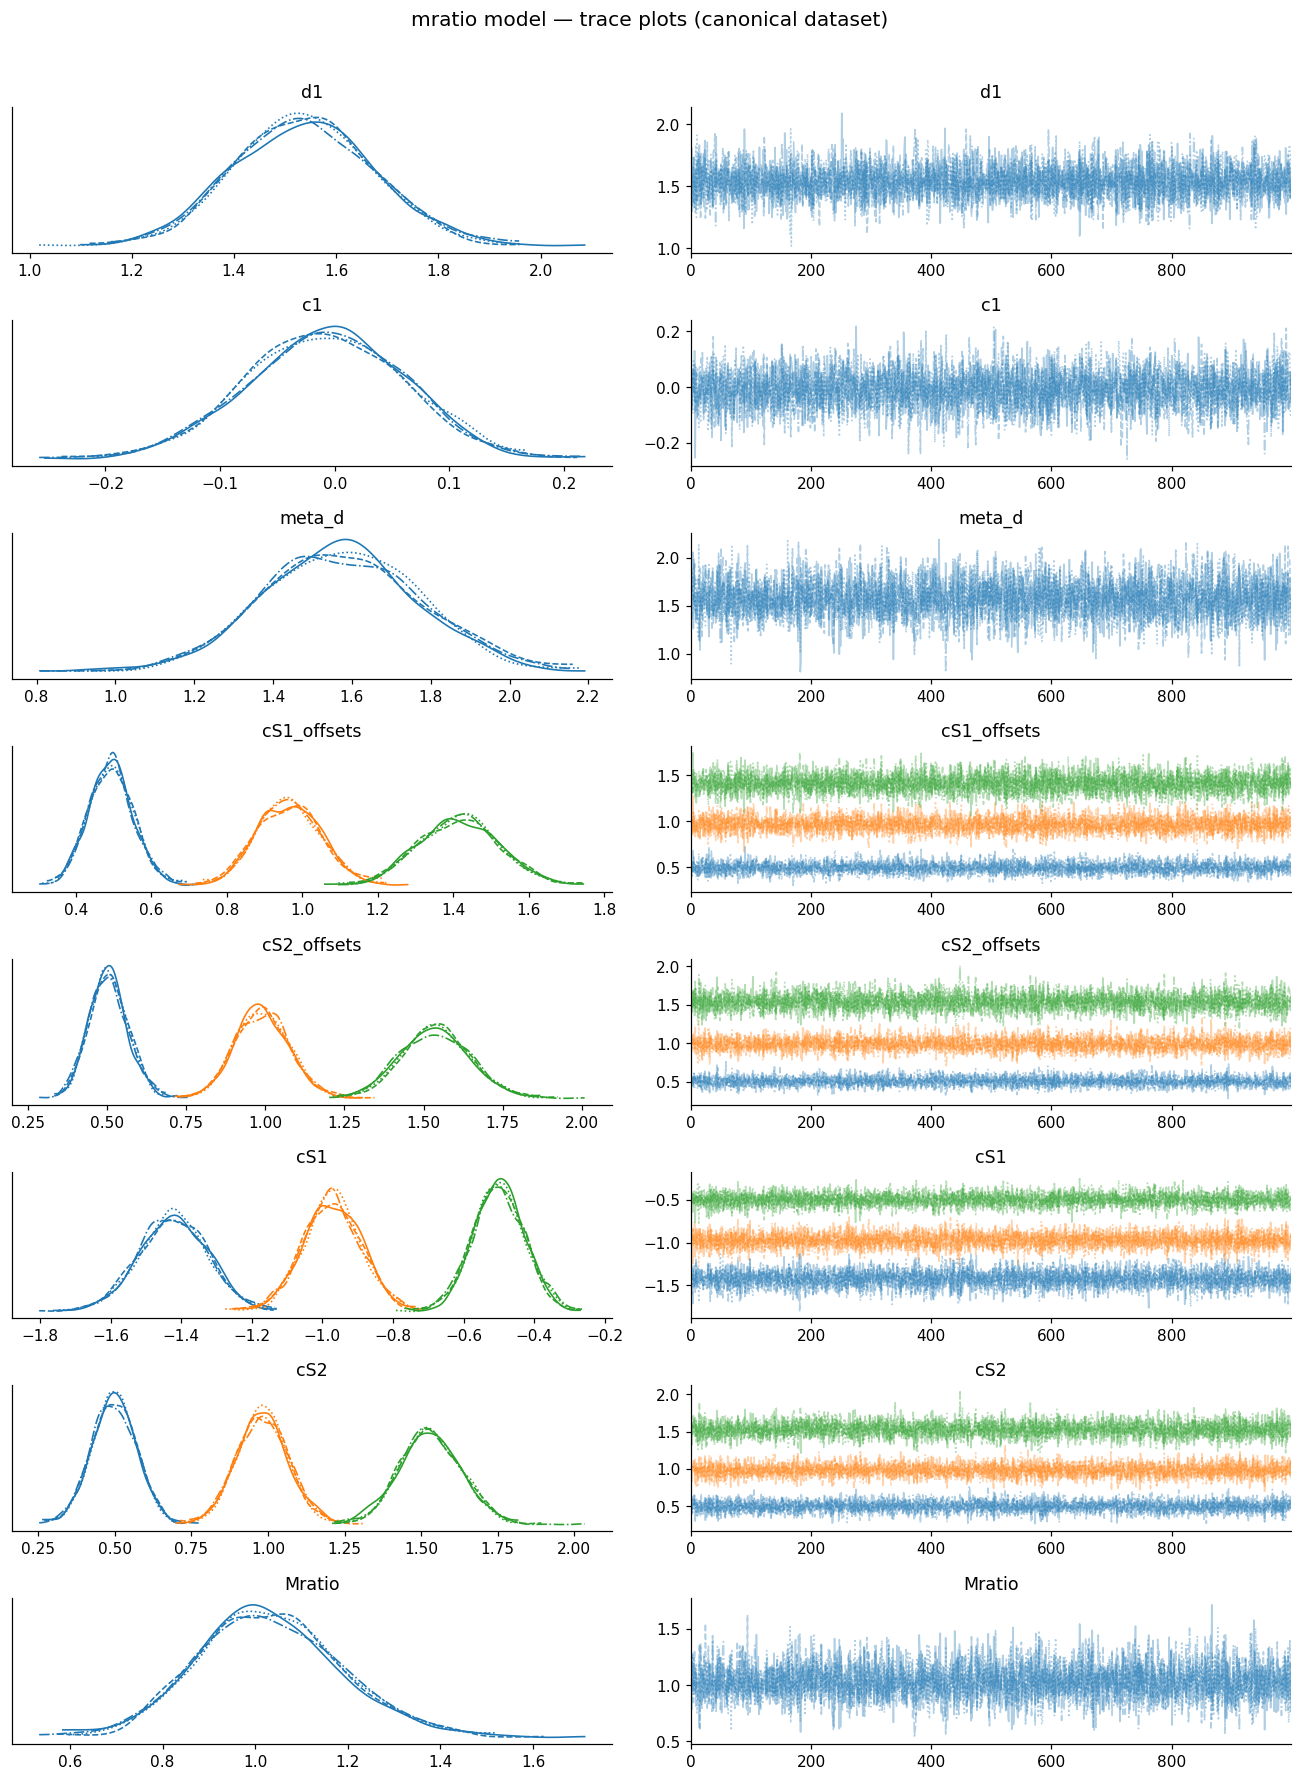

In [9]:
# Trace plots for mratio model
if fit_mratio.idata is not None:
    az.plot_trace(fit_mratio.idata, compact=True)
    plt.suptitle("mratio model — trace plots (canonical dataset)", y=1.01)
    plt.tight_layout()
    plt.show()

In [10]:
# metadpy published Bayesian posterior (Example 2, PyMC NUTS)
metadpy_bayes = {"meta_d": (1.567, 0.201), "d1": (1.534, 0.135), "c1": (-0.006, 0.066)}

print("Parameter comparison — metasignal (mratio/Stan) vs metadpy (PyMC):")
print(f"{'Parameter':<14} {'metasignal mean':>17} {'metadpy mean':>14} {'metadpy SD':>12}")
print("-" * 60)

if fit_mratio.idata is not None:
    sumdf = az.summary(fit_mratio.idata, round_to=4)
    for param, (ref_mean, ref_sd) in metadpy_bayes.items():
        # try to find the variable in summary
        matches = [v for v in sumdf.index if param in v.lower()]
        our_mean = sumdf.loc[matches[0], "mean"] if matches else float("nan")
        print(f"{param:<14} {our_mean:>17.3f} {ref_mean:>14.3f} {ref_sd:>12.3f}")
else:
    print("(run cell above to get idata)")
print()
print("Both samplers use the same priors and multinomial SDT likelihood.")
print("Differences arise only from MCMC noise between NUTS samplers.")

Parameter comparison — metasignal (mratio/Stan) vs metadpy (PyMC):
Parameter        metasignal mean   metadpy mean   metadpy SD
------------------------------------------------------------
meta_d                     1.573          1.567        0.201
d1                         1.537          1.534        0.135
c1                        -0.008         -0.006        0.066

Both samplers use the same priors and multinomial SDT likelihood.
Differences arise only from MCMC noise between NUTS samplers.


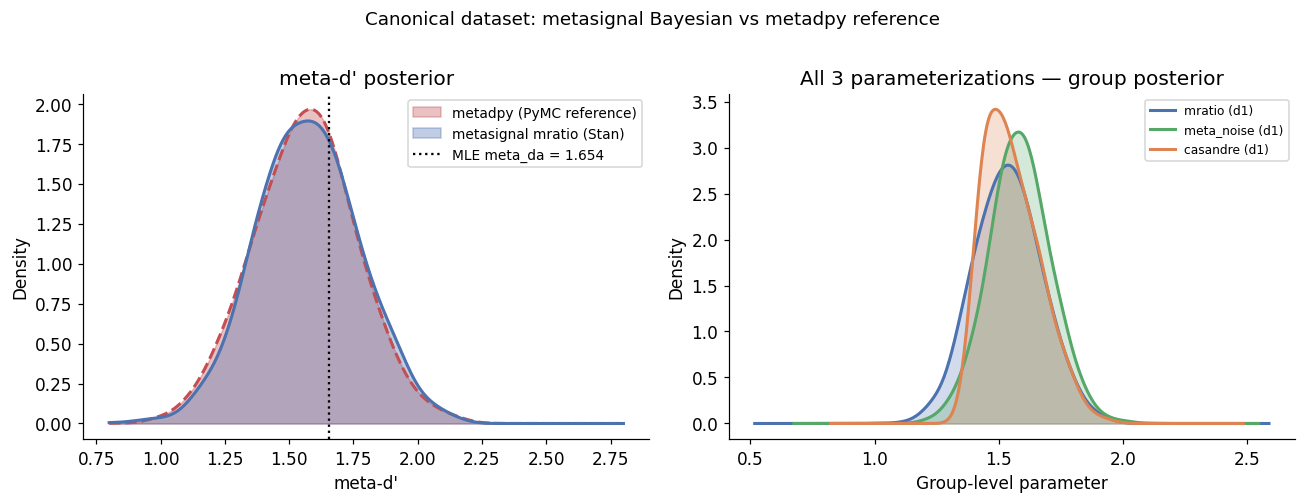

In [11]:
# Posterior density overlay: mratio model vs metadpy reference
from scipy import stats as scipy_stats

metadpy_meta_d_mean, metadpy_meta_d_sd = 1.567, 0.201
x_m = np.linspace(0.8, 2.8, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Extract mratio samples
if fit_mratio.idata is not None:
    post = az.extract(fit_mratio.idata)
    # find meta_d variable
    meta_d_var = [v for v in post.data_vars if "meta" in v.lower()]
    if meta_d_var:
        our_meta_d = post[meta_d_var[0]].values.ravel()
    else:
        our_meta_d = None
else:
    our_meta_d = None

# Simulate metadpy reference
ref_meta_d = RNG.normal(metadpy_meta_d_mean, metadpy_meta_d_sd, 4000)

ax = axes[0]
kde_ref = scipy_stats.gaussian_kde(ref_meta_d, bw_method=0.25)
ax.fill_between(x_m, kde_ref(x_m), alpha=0.35, color="#C44E52",
                label="metadpy (PyMC reference)")
ax.plot(x_m, kde_ref(x_m), lw=2, color="#C44E52", ls="--")

if our_meta_d is not None:
    kde_ours = scipy_stats.gaussian_kde(our_meta_d, bw_method=0.25)
    ax.fill_between(x_m, kde_ours(x_m), alpha=0.35, color="#4C72B0",
                    label="metasignal mratio (Stan)")
    ax.plot(x_m, kde_ours(x_m), lw=2, color="#4C72B0")

ax.axvline(mle["meta_da"], color="black", lw=1.5, ls=":",
           label=f"MLE meta_da = {mle['meta_da']:.3f}")
ax.set_xlabel("meta-d'"); ax.set_ylabel("Density")
ax.set_title("meta-d' posterior")
ax.legend(fontsize=9)

# All 3 parameterizations: extract group meta parameter
ax = axes[1]
colors = {"mratio": "#4C72B0", "meta_noise": "#55A868", "casandre": "#DD8452"}
for label, fit_obj in [("mratio", fit_mratio), ("meta_noise", fit_noise), ("casandre", fit_casandre)]:
    if fit_obj.idata is None:
        continue
    p = az.extract(fit_obj.idata)
    # get the first group-level parameter
    group_vars = [v for v in p.data_vars]
    if not group_vars:
        continue
    vals = p[group_vars[0]].values.ravel()
    if len(vals) == 0:
        continue
    x_range = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 400)
    kde = scipy_stats.gaussian_kde(vals, bw_method=0.3)
    ax.fill_between(x_range, kde(x_range), alpha=0.25, color=colors[label])
    ax.plot(x_range, kde(x_range), lw=2, color=colors[label], label=f"{label} ({group_vars[0]})")

ax.set_xlabel("Group-level parameter"); ax.set_ylabel("Density")
ax.set_title("All 3 parameterizations — group posterior")
ax.legend(fontsize=8)

plt.suptitle("Canonical dataset: metasignal Bayesian vs metadpy reference", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Group-Level Analysis — `rm` Dataset

Same repeated-measures dataset as metadpy's group-level examples:
20 subjects × 2 conditions, ~100 trials each.

In [12]:
import pathlib

rm_path = pathlib.Path("rm.txt")
if not rm_path.exists():
    rm_path = pathlib.Path(__file__).parent / "rm.txt" if "__file__" in dir() else pathlib.Path("docs/tutorials/rm.txt")

rm = pd.read_csv(rm_path)
print(rm.head())
print(f"\n{rm['Subject'].nunique()} subjects × {rm['Condition'].nunique()} conditions")
print(f"{len(rm)} total trials")

   Stimuli  Responses  Accuracy  Confidence  nTrial  Subject  Condition
0        0          0         1           4       0        0          0
1        1          1         1           4       1        0          0
2        0          1         0           4       2        0          0
3        1          0         0           1       3        0          0
4        1          1         1           2       4        0          0

20 subjects × 2 conditions
4000 total trials


In [13]:
# MLE per subject × condition
mle_results = stdpy.fit_group(
    rm,
    stimuli="Stimuli", responses="Responses", confidence="Confidence",
    nRatings=n_ratings, subject="Subject", within="Condition",
)
print(mle_results[["Subject", "Condition", "dprime", "meta_d", "M_ratio"]].to_string())

    Subject  Condition    dprime    meta_d   M_ratio
0         0          0  1.001804  0.796462  0.795028
1         0          1  1.050540  0.880347  0.837994
2         1          0  1.167746  1.134184  0.993105
3         1          1  1.011783  0.908388  0.918209
4         2          0  0.826158  0.699682  0.864891
5         2          1  0.992099  0.410329  0.413596
6         3          0  1.107242  1.526084  1.408829
7         3          1  0.936864  0.889264  0.969679
8         4          0  0.995305  0.747512  0.751039
9         4          1  0.826158  0.703400  0.869486
10        5          0  0.941300  0.902319  0.979499
11        5          1  0.948826  0.864262  0.931105
12        6          0  1.001804  1.155290  1.178826
13        6          1  0.935398  1.058575  1.156023
14        7          0  1.048801  0.880394  0.839429
15        7          1  1.107242  0.677863  0.612209
16        8          0  0.941300  1.236445  1.342204
17        8          1  0.935398  0.535700  0.

In [14]:
# Per-condition MLE summary
summary = mle_results.groupby("Condition")[["dprime", "M_ratio", "meta_d"]].agg(["mean", "std"])
print(summary.round(3))

          dprime        M_ratio        meta_d       
            mean    std    mean    std   mean    std
Condition                                           
0          1.003  0.100   1.010  0.286  1.009  0.343
1          1.003  0.093   0.662  0.404  0.645  0.406


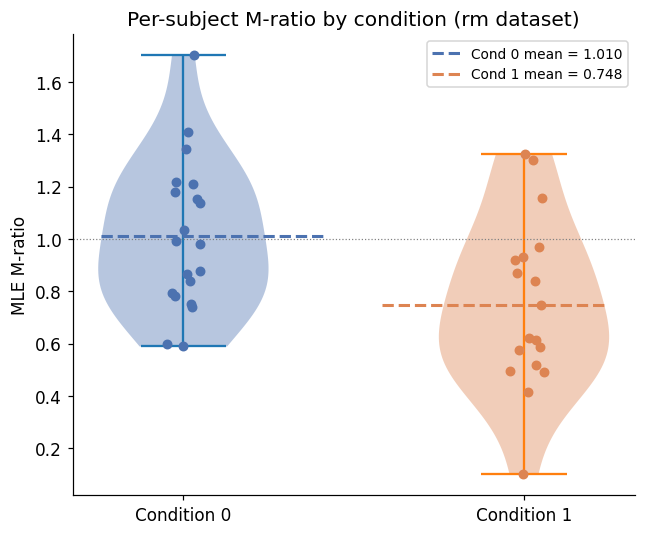

In [15]:
# Violin + strip: MLE M-ratio by condition
fig, ax = plt.subplots(figsize=(6, 5))
for i, cond in enumerate(sorted(rm["Condition"].unique())):
    vals = mle_results.loc[mle_results["Condition"] == cond, "M_ratio"].dropna().values
    vals = vals[vals > 0]
    parts = ax.violinplot([vals], positions=[i], widths=0.5,
                          showmeans=False, showmedians=False)
    for body in parts["bodies"]:
        body.set_facecolor(["#4C72B0", "#DD8452"][i])
        body.set_alpha(0.4)
    jitter = RNG.uniform(-0.06, 0.06, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=["#4C72B0", "#DD8452"][i], s=30, zorder=3)
    ax.axhline(vals.mean(), xmin=i/2 + 0.05, xmax=(i+1)/2 - 0.05,
               color=["#4C72B0", "#DD8452"][i], lw=2, ls="--",
               label=f"Cond {cond} mean = {vals.mean():.3f}")

ax.axhline(1.0, color="gray", lw=0.8, ls=":")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Condition 0", "Condition 1"])
ax.set_ylabel("MLE M-ratio"); ax.set_title("Per-subject M-ratio by condition (rm dataset)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Group Bayesian — mratio (rm dataset)

Fit a hierarchical mratio model across all subjects with `Condition` as a
between-/within-subject predictor.

In [16]:
# Fit separately per condition for interpretability (mirrors metadpy group tutorial)
cond0 = rm[rm["Condition"] == 0].copy()
cond1 = rm[rm["Condition"] == 1].copy()

fit_grp0 = fit_group(
    cond0,
    stimuli="Stimuli", responses="Responses", confidence="Confidence",
    nRatings=n_ratings, subject="Subject",
    method="bayesian", parameterization="mratio",
    chains=4, n_iter=2000, warmup=1000, seed=42,
)
print("Condition 0 fit:", type(fit_grp0).__name__)

21:43:07 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:43:27 - cmdstanpy - INFO - CmdStan done processing.


21:43:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multinomial_logit_lpmf: log-probabilities parameter[2] is -inf, but must be finite! (in 'hmeta_d.stan', line 220, column 8 to column 104)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[2] is -inf, but must be finite! (in 'hmeta_d.stan', line 220, column 8 to column 104)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[1] is -inf, but must be finite! (in 'hmeta_d.stan', line 221, column 8 to column 105)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[1] is -inf, but must be finite! (in 'hmeta_d.stan', line 221, column 8 to column 105)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[4] is -inf, but must be finite! (in 'hmeta_d.stan', line 221, column 8 to column 105)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hmeta_d.stan', line 164, column 8 to column 49)
	Exception: multinomial_logit_lpmf: log-probabilities parame

Condition 0 fit: FitResult


In [17]:
fit_grp1 = fit_group(
    cond1,
    stimuli="Stimuli", responses="Responses", confidence="Confidence",
    nRatings=n_ratings, subject="Subject",
    method="bayesian", parameterization="mratio",
    chains=4, n_iter=2000, warmup=1000, seed=42,
)
print("Condition 1 fit:", type(fit_grp1).__name__)

21:43:27 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

21:43:53 - cmdstanpy - INFO - CmdStan done processing.


21:43:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multinomial_logit_lpmf: log-probabilities parameter[2] is -inf, but must be finite! (in 'hmeta_d.stan', line 220, column 8 to column 104)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[2] is -inf, but must be finite! (in 'hmeta_d.stan', line 220, column 8 to column 104)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[1] is -inf, but must be finite! (in 'hmeta_d.stan', line 221, column 8 to column 105)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[1] is -inf, but must be finite! (in 'hmeta_d.stan', line 221, column 8 to column 105)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hmeta_d.stan', line 164, column 8 to column 49)
	Exception: multinomial_logit_lpmf: log-probabilities parameter[2] is -inf, but must be finite! (in 'hmeta_d.stan', line 220, column 8 to column 104)
	Exception: multinomial_logit_lpmf: log-probabilities parame

21:43:53 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 5 divergent transitions (0.5%)
	Chain 3 had 3 divergent transitions (0.3%)
	Chain 4 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Condition 1 fit: FitResult


In [18]:
# Posterior summaries
for label, fit_obj in [("Condition 0", fit_grp0), ("Condition 1", fit_grp1)]:
    if fit_obj.idata is not None:
        print(f"\n=== {label} ===")
        print(az.summary(fit_obj.idata, round_to=3).to_string())


=== Condition 0 ===


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu_d1               0.997  0.061   0.883    1.111      0.001    0.001  5962.616  3430.514  1.000
sigma_d1            0.057  0.044   0.000    0.135      0.001    0.001  2669.280  2199.950  1.000
d1_z[0]            -0.060  0.959  -1.833    1.790      0.011    0.019  7268.657  2671.177  1.003
d1_z[1]             0.152  0.969  -1.689    1.927      0.011    0.020  7458.055  2946.436  1.004
d1_z[2]            -0.228  0.965  -2.218    1.444      0.011    0.016  7375.839  2989.221  1.000
d1_z[3]             0.239  0.951  -1.500    1.997      0.010    0.016  8345.298  2829.070  1.000
d1_z[4]            -0.084  0.982  -1.931    1.659      0.013    0.018  5703.472  2347.803  0.999
d1_z[5]            -0.091  0.993  -1.990    1.740      0.012    0.022  7017.681  2298.342  1.001
d1_z[6]             0.021  0.967  -1.708    1.909      0.012    0.017  6850.336  2955.540  1.001
d1_z[7]             0.010  0.9

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu_d1               0.997  0.060   0.889    1.114      0.001    0.001  5739.285  2987.523  1.001
sigma_d1            0.053  0.042   0.000    0.128      0.001    0.001  2623.702  1873.776  1.002
d1_z[0]             0.054  0.986  -1.732    1.941      0.013    0.018  5581.926  2666.493  1.000
d1_z[1]             0.033  0.979  -1.876    1.765      0.013    0.017  6034.026  3004.749  1.002
d1_z[2]            -0.021  0.964  -1.871    1.805      0.013    0.017  5491.334  2822.833  1.001
d1_z[3]             0.014  0.957  -1.755    1.849      0.013    0.016  5108.998  2713.104  1.000
d1_z[4]            -0.099  0.967  -2.052    1.593      0.014    0.017  5042.345  2276.555  1.001
d1_z[5]            -0.009  0.944  -1.706    1.828      0.012    0.016  5735.497  2777.059  1.000
d1_z[6]             0.051  0.984  -1.872    1.825      0.012    0.017  6298.309  2776.279  1.003
d1_z[7]             0.078  0.9

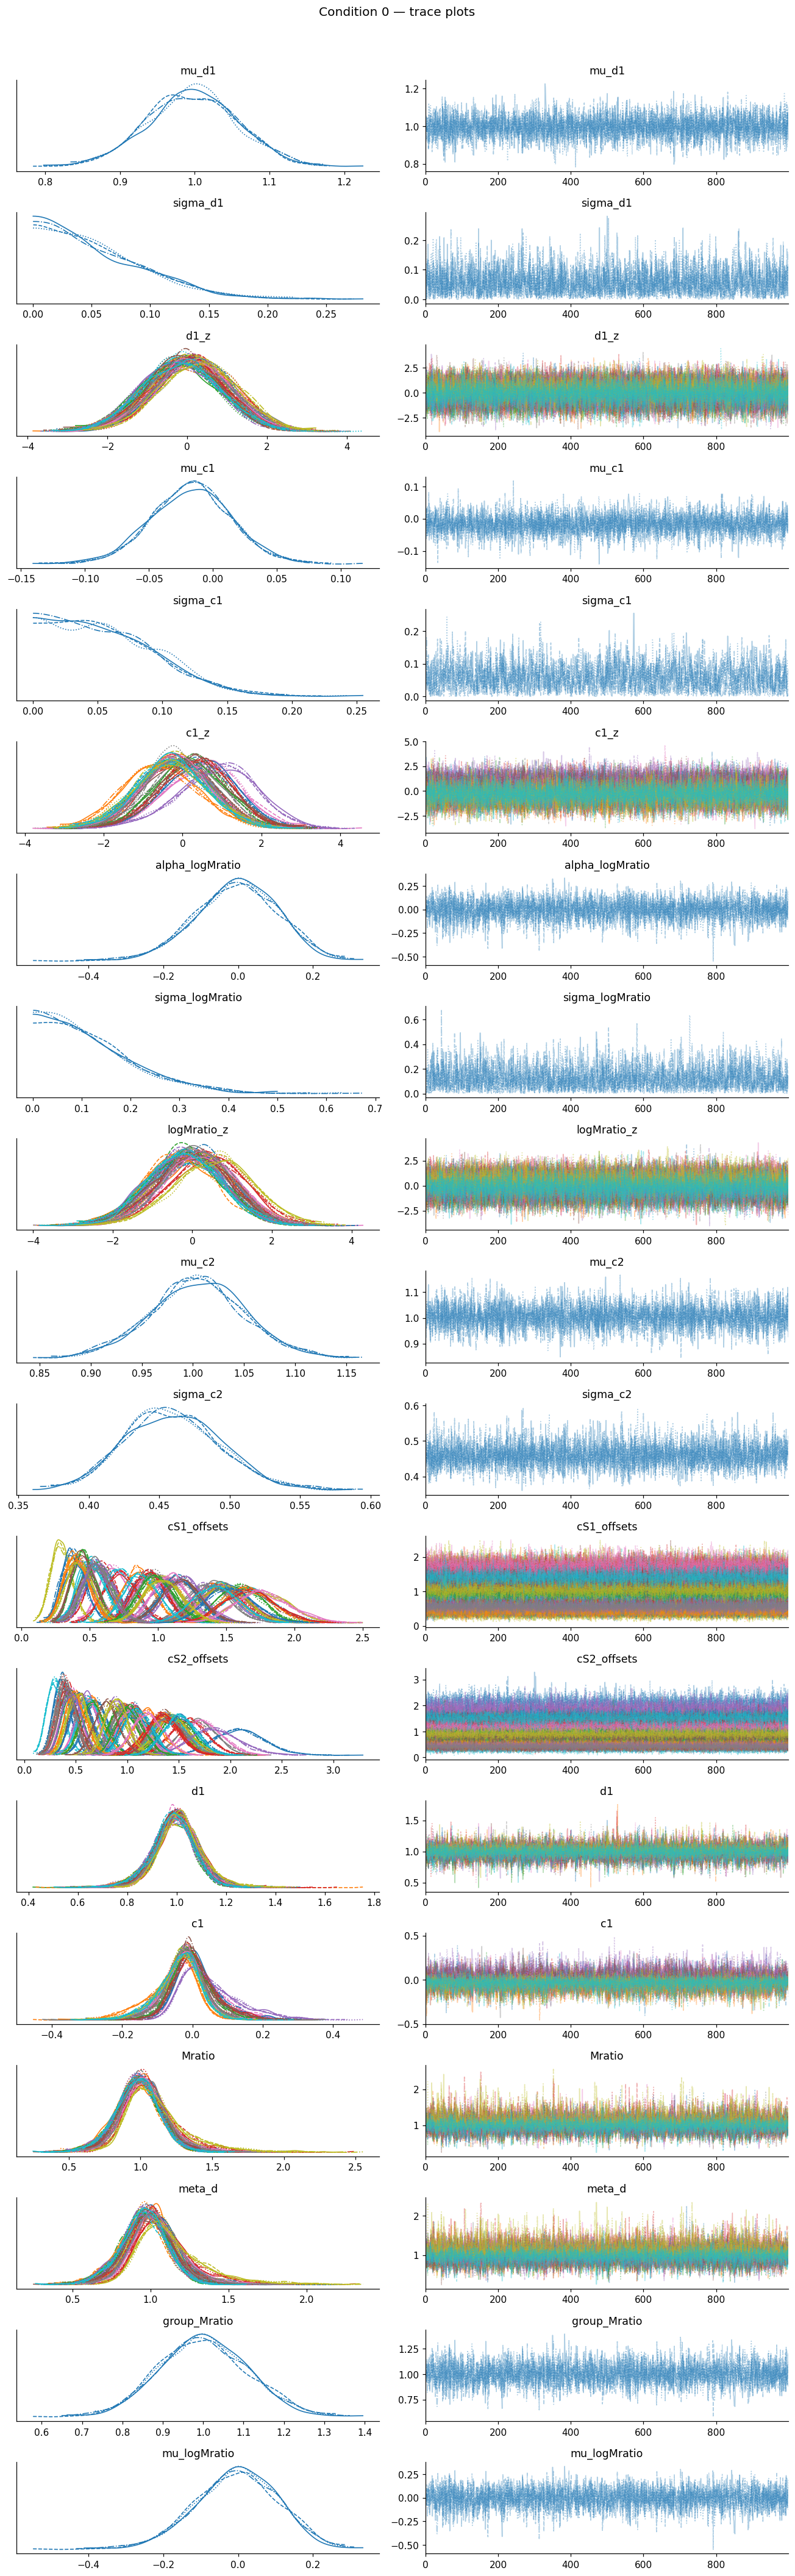

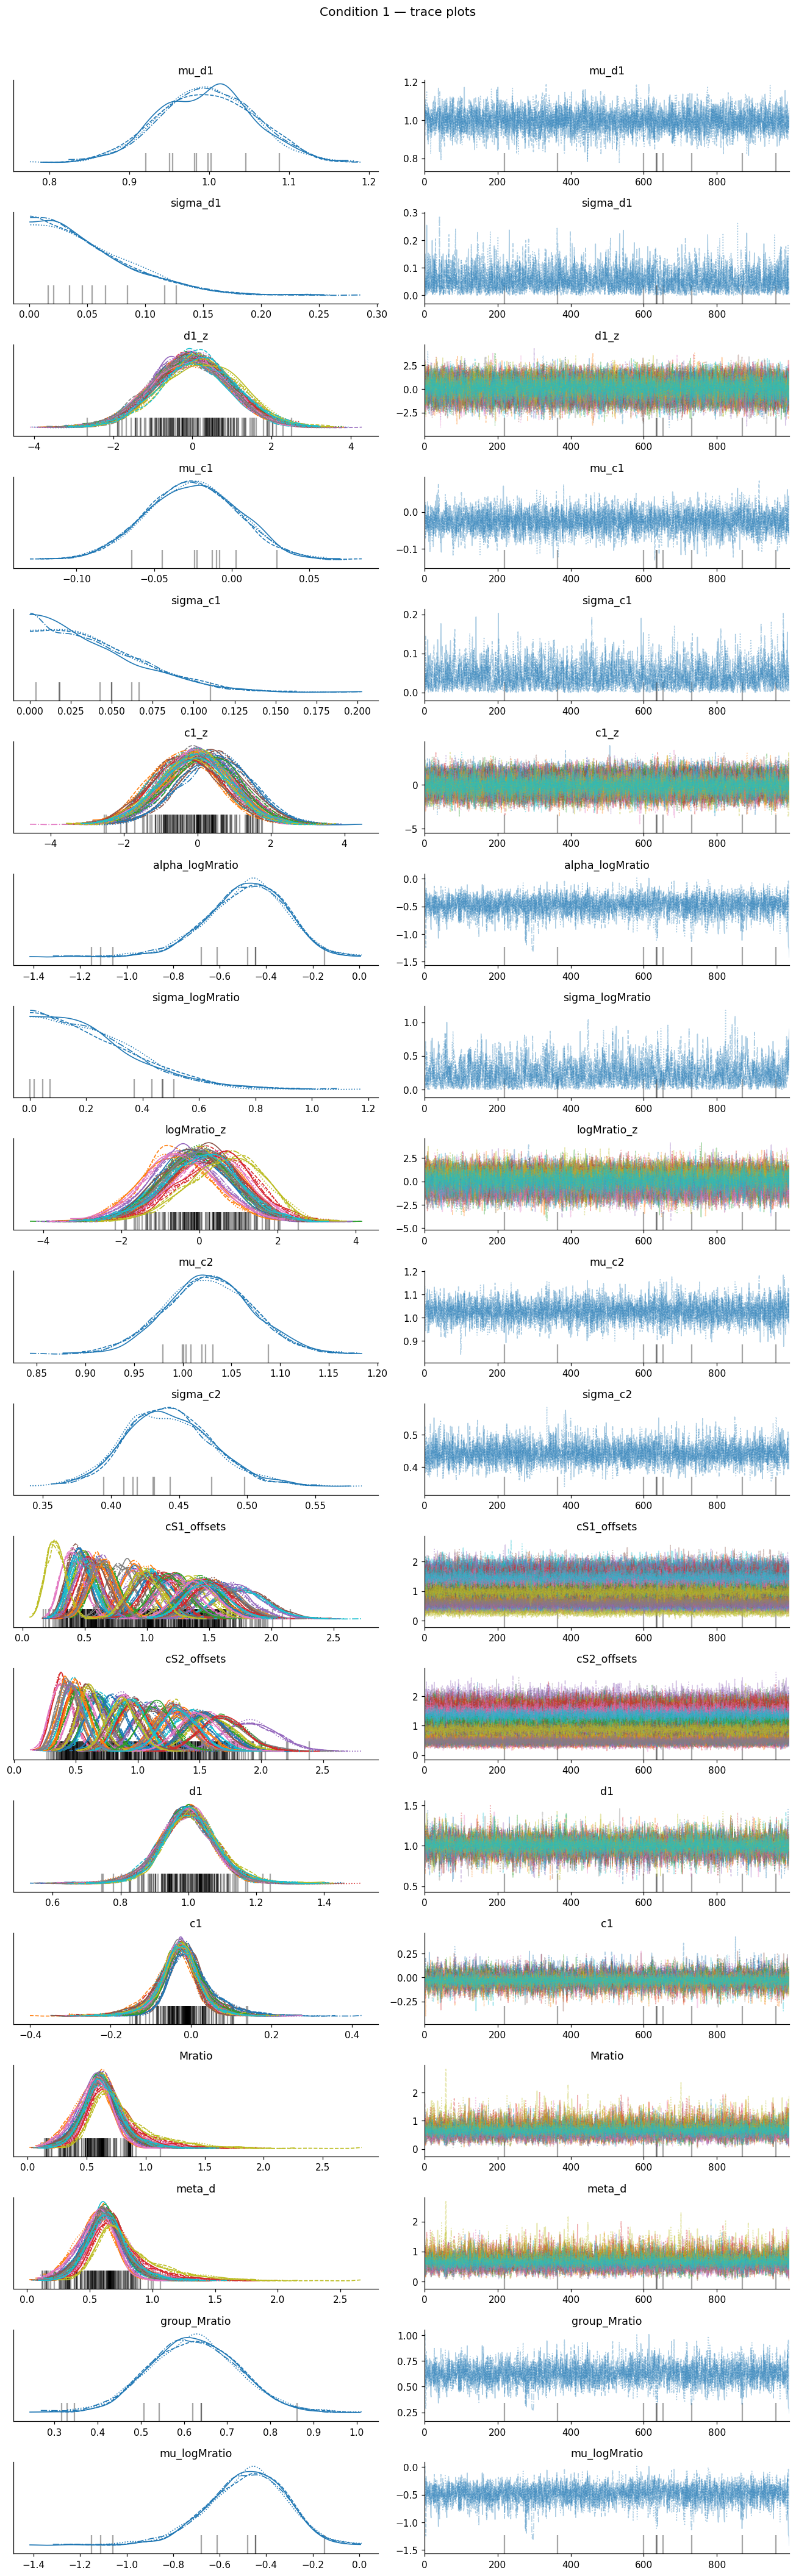

In [19]:
# Trace plots
for label, fit_obj in [("Condition 0", fit_grp0), ("Condition 1", fit_grp1)]:
    if fit_obj.idata is not None:
        az.plot_trace(fit_obj.idata, compact=True)
        plt.suptitle(f"{label} — trace plots", y=1.01)
        plt.tight_layout()
        plt.show()

## 8. Group Comparison — Posterior Difference (Cond 1 − Cond 0)

Group-level variable: Cond0=mu_d1, Cond1=mu_d1
delta mean = 0.000  SD = 0.085
95% HDI: -0.169 – 0.164
P(Cond1 < Cond0) = 0.496


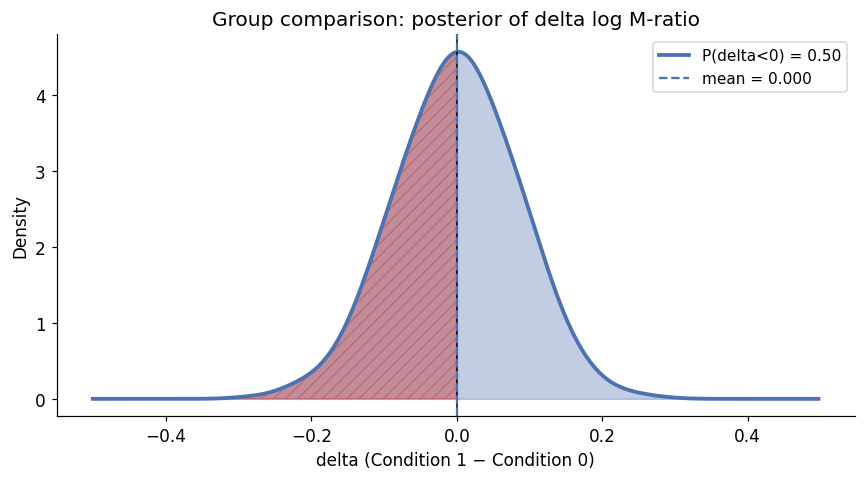

In [20]:
if fit_grp0.idata is not None and fit_grp1.idata is not None:
    p0 = az.extract(fit_grp0.idata)
    p1 = az.extract(fit_grp1.idata)

    # find group-level log M-ratio variable (first variable in each)
    g0_var = list(p0.data_vars)[0]
    g1_var = list(p1.data_vars)[0]

    s0 = p0[g0_var].values.ravel()
    s1 = p1[g1_var].values.ravel()

    # match sample sizes
    n = min(len(s0), len(s1))
    delta = s1[:n] - s0[:n]

    p_lower = (delta < 0).mean()
    print(f"Group-level variable: Cond0={g0_var}, Cond1={g1_var}")
    print(f"delta mean = {delta.mean():.3f}  SD = {delta.std():.3f}")
    print(f"95% HDI: {np.percentile(delta, 2.5):.3f} – {np.percentile(delta, 97.5):.3f}")
    print(f"P(Cond1 < Cond0) = {p_lower:.3f}")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x_d = np.linspace(delta.min() - 0.2, delta.max() + 0.2, 400)
    kde_d = scipy_stats.gaussian_kde(delta, bw_method=0.3)
    ax.fill_between(x_d, kde_d(x_d), alpha=0.35, color="#4C72B0")
    ax.plot(x_d, kde_d(x_d), lw=2.5, color="#4C72B0",
            label=f"P(delta<0) = {p_lower:.2f}")
    x_neg = x_d[x_d < 0]
    ax.fill_between(x_neg, kde_d(x_neg), alpha=0.5, color="#C44E52", hatch="///")
    ax.axvline(0, color="black", lw=1)
    ax.axvline(delta.mean(), color="#4C72B0", lw=1.5, ls="--",
               label=f"mean = {delta.mean():.3f}")
    ax.set_xlabel("delta (Condition 1 − Condition 0)")
    ax.set_ylabel("Density")
    ax.set_title("Group comparison: posterior of delta log M-ratio")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## 9. Summary

| Method | API | Backend | Notes |
|--------|-----|---------|-------|
| MLE | `fit_meta_d_mle` / `fit_group` | scipy | Fast point estimates, no uncertainty |
| Bayesian mratio | `fit_group(..., parameterization='mratio')` | cmdstanpy Stan | Direct equivalent of metadpy `hmetad()` |
| Bayesian meta_noise | `fit_group(..., parameterization='meta_noise')` | cmdstanpy Stan | Additive-noise parameterization |
| Bayesian casandre | `fit_group(..., parameterization='casandre')` | cmdstanpy Stan | Meta-uncertainty (Boundy-Singer 2023) |

All Bayesian fits return a `FitResult` with `.idata` (ArviZ `InferenceData`)
so any ArviZ diagnostic function works directly:

```python
az.plot_trace(fit.idata)
az.summary(fit.idata)
az.plot_posterior(fit.idata)
```